# Compare one selected segment across three data roots

This notebook selects the first exported segment matching a user, label, and dataset ID in path A. It plots:

- path A raw acceleration (`SpikeIMU[:, 15:18]`);
- path A reconstruction;
- path B reconstruction;
- path C reconstruction.

The three paths must contain the same segment identity. Reconstruction is loaded from the published padded reconstruction when available, with the unpadded reconstruction as a fallback.

In [5]:
from __future__ import annotations

from dataclasses import dataclass
import json
import math
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

## Settings

Change the three roots and the selection fields here. `PLOT_ENABLED=False` keeps all loading and validation but skips the figure. Roots may be either the output base (for example `outputs/action0_rectified_default_wavelets`) or the full combination root ending in `low-pass/aligned-board-events`.

In [6]:
# Three output roots. Relative paths are resolved from the repository root.
DATA_ROOT_A = Path("outputs/action0_rectified_default_wavelets")
DATA_ROOT_B = Path("outputs/action0_rectified_default_wavelets_absrectify")
DATA_ROOT_C = Path("outputs/action0_rectified_new_wavelets")

ACTION = 0
USER = "user_0"
LABEL = "f"
DATASET_ID = 0

# Select the first exported segment with this exact dataset_id and label.
PLOT_ENABLED = True
SAVE_FIGURE = False
OUTPUT_FIGURE = Path("outputs/selected_segment_three_path_reconstruction.png")

GRAVITY_METHOD = "low-pass"
BOUNDARY_MODE = "aligned-board-events"
REPO_ROOT_OVERRIDE: str | Path | None = None

In [7]:
SPIKE_CHANNEL_COUNT = 21
ACCELERATION_SLICE = slice(15, 18)
AXIS_NAMES = ("x", "y", "z")
RECONSTRUCTION_SUFFIX = "_reconstructed_accel_m_s2.npy"
PADDED_RECONSTRUCTION_SUFFIX = "_padded_reconstructed_accel_m_s2.npy"


@dataclass(frozen=True)
class SegmentIdentity:
    user: str
    action: int
    dataset_id: int
    label: str
    segment_index: int


def find_repo_root(override: str | Path | None = None) -> Path:
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not (root / "src/writingring").is_dir():
            raise FileNotFoundError(f"Not a WritingRing repository root: {root}")
        return root

    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src/writingring").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root. Set REPO_ROOT_OVERRIDE in the settings cell."
    )


REPO_ROOT = find_repo_root(REPO_ROOT_OVERRIDE)


def resolve_path(value: str | Path) -> Path:
    path = Path(value).expanduser()
    return (path if path.is_absolute() else REPO_ROOT / path).resolve()


def resolve_combination_root(value: str | Path) -> Path:
    base = resolve_path(value)
    candidates = [
        base,
        base / BOUNDARY_MODE,
        base / GRAVITY_METHOD / BOUNDARY_MODE,
    ]
    matches = [
        candidate
        for candidate in candidates
        if (candidate / "segmentation").is_dir()
        and (candidate / "segmentation_padded").is_dir()
    ]
    unique_matches = list(dict.fromkeys(matches))
    if len(unique_matches) == 1:
        return unique_matches[0]
    if not unique_matches:
        raise FileNotFoundError(
            f"Could not resolve a combination root from {base}. "
            "Expected segmentation/ and segmentation_padded/."
        )
    raise RuntimeError(
        f"Multiple combination roots matched {base}: {unique_matches}. "
        "Set the full low-pass/aligned-board-events path explicitly."
    )


def package_paths(combination_root: Path, user: str, action: int) -> dict[str, Path]:
    action_text = str(action)
    prefix = f"{user}_action_{action_text}"
    segmentation_dir = combination_root / "segmentation" / user / f"action_{action_text}"
    padded_dir = combination_root / "segmentation_padded" / user / f"action_{action_text}"
    return {
        "prefix": Path(prefix),
        "segmentation_dir": segmentation_dir,
        "padded_dir": padded_dir,
        "spike": segmentation_dir / f"{prefix}_spikeIMU.npy",
        "offsets": segmentation_dir / f"{prefix}_segment_offsets.npy",
        "labels": segmentation_dir / f"{prefix}_labels.npy",
        "summary": segmentation_dir / f"{prefix}_segmentation_summary.json",
        "segments": segmentation_dir / f"{prefix}_segments.csv",
        "padding_manifest": padded_dir / f"{prefix}_padding_manifest.csv",
        "padded_reconstruction": padded_dir / f"{prefix}{PADDED_RECONSTRUCTION_SUFFIX}",
        "reconstruction": segmentation_dir / f"{prefix}{RECONSTRUCTION_SUFFIX}",
    }


def require_files(paths: list[Path]) -> None:
    missing = [str(path) for path in paths if not path.is_file()]
    if missing:
        raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))


def as_bool(value: Any) -> bool:
    if isinstance(value, bool):
        return value
    text = str(value).strip().lower()
    if text in {"true", "1", "yes"}:
        return True
    if text in {"false", "0", "no", "nan", "none"}:
        return False
    raise ValueError(f"Cannot parse boolean value: {value!r}")


def integer_column(frame: pd.DataFrame, name: str) -> pd.Series:
    values = pd.to_numeric(frame[name], errors="coerce")
    if values.isna().any():
        raise ValueError(f"Column {name!r} contains non-numeric values")
    return values.astype(np.int64)


def exported_segments(paths: dict[str, Path]) -> pd.DataFrame:
    require_files([
        paths["segments"],
        paths["spike"],
        paths["offsets"],
        paths["labels"],
        paths["summary"],
    ])
    frame = pd.read_csv(paths["segments"])
    required_columns = {"segment_index", "exported", "dataset_id", "label"}
    missing = sorted(required_columns - set(frame.columns))
    if missing:
        raise ValueError(f"{paths['segments']}: missing columns {missing}")
    frame = frame.copy()
    frame["dataset_id"] = integer_column(frame, "dataset_id")
    frame["exported"] = frame["exported"].map(as_bool)
    frame["label"] = frame["label"].astype(str)
    frame = frame.loc[frame["exported"]].copy()
    frame["segment_index"] = integer_column(frame, "segment_index")
    return frame.sort_values("segment_index").reset_index(drop=True)


def first_matching_segment(
    frame: pd.DataFrame,
    *,
    user: str,
    action: int,
    dataset_id: int,
    label: str,
) -> SegmentIdentity:
    matches = frame.loc[
        (frame["dataset_id"] == int(dataset_id))
        & (frame["label"] == str(label))
    ].sort_values("segment_index")
    if matches.empty:
        available = frame.loc[
            frame["dataset_id"] == int(dataset_id),
            ["segment_index", "label"],
        ]
        raise ValueError(
            f"No exported segment found for user={user!r}, action={action}, "
            f"dataset_id={dataset_id}, label={label!r}.\n"
            f"Available rows:\n{available.to_string(index=False)}"
        )
    row = matches.iloc[0]
    return SegmentIdentity(
        user=user,
        action=int(action),
        dataset_id=int(row["dataset_id"]),
        label=str(row["label"]),
        segment_index=int(row["segment_index"]),
    )


def matching_row(frame: pd.DataFrame, identity: SegmentIdentity) -> pd.Series:
    matches = frame.loc[
        (frame["segment_index"] == identity.segment_index)
        & (frame["dataset_id"] == identity.dataset_id)
        & (frame["label"] == identity.label)
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one matching segment in a comparison path, got {len(matches)} "
            f"for {identity}."
        )
    return matches.iloc[0]


def load_a_raw(
    paths: dict[str, Path],
    identity: SegmentIdentity,
) -> tuple[np.ndarray, float, pd.Series]:
    spike_imu = np.load(paths["spike"], allow_pickle=False)
    offsets = np.load(paths["offsets"], allow_pickle=False).astype(np.int64)
    summary = json.loads(paths["summary"].read_text(encoding="utf-8"))
    if spike_imu.ndim != 2 or spike_imu.shape[1] != SPIKE_CHANNEL_COUNT:
        raise ValueError(f"Expected SpikeIMU shape (N, 21), got {spike_imu.shape}")
    if offsets.ndim != 1 or offsets[0] != 0 or offsets[-1] != len(spike_imu):
        raise ValueError(f"Invalid segment offsets: {paths['offsets']}")
    row = matching_row(exported_segments(paths), identity)
    start = int(offsets[identity.segment_index])
    stop = int(offsets[identity.segment_index + 1])
    raw = np.asarray(spike_imu[start:stop, ACCELERATION_SLICE], dtype=np.float64)
    if raw.ndim != 2 or raw.shape[1] != 3 or len(raw) == 0 or not np.isfinite(raw).all():
        raise ValueError(f"Invalid raw acceleration segment: {raw.shape}")
    sampling_rate_hz = float(summary.get("sampling_rate_hz", float("nan")))
    if not math.isfinite(sampling_rate_hz) or sampling_rate_hz <= 0:
        raise ValueError(f"Invalid sampling_rate_hz in {paths['summary']}")
    return raw, sampling_rate_hz, row


def load_reconstruction(
    paths: dict[str, Path],
    identity: SegmentIdentity,
) -> np.ndarray:
    if paths["padding_manifest"].is_file() and paths["padded_reconstruction"].is_file():
        manifest = pd.read_csv(paths["padding_manifest"])
        manifest["segment_index"] = integer_column(manifest, "segment_index")
        manifest["dataset_id"] = integer_column(manifest, "dataset_id")
        manifest["label"] = manifest["label"].astype(str)
        padded_row = manifest.loc[
            (manifest["segment_index"] == identity.segment_index)
            & (manifest["dataset_id"] == identity.dataset_id)
            & (manifest["label"] == identity.label)
        ]
        if len(padded_row) == 1 and as_bool(padded_row.iloc[0]["exported"]):
            output_index_value = padded_row.iloc[0]["output_segment_index"]
            if pd.notna(output_index_value):
                output_index = int(output_index_value)
                padded = np.load(paths["padded_reconstruction"], allow_pickle=False)
                if padded.ndim != 3 or padded.shape[2] != 3:
                    raise ValueError(
                        f"Expected padded reconstruction shape (S, T, 3), got {padded.shape}"
                    )
                original_length = int(padded_row.iloc[0]["original_length"])
                values = np.asarray(padded[output_index, :original_length], dtype=np.float64)
                if values.shape == (original_length, 3):
                    if not np.isfinite(values).all():
                        raise ValueError(f"Non-finite padded reconstruction: {paths['padded_reconstruction']}")
                    return values

    if paths["reconstruction"].is_file():
        reconstruction = np.load(paths["reconstruction"], allow_pickle=False)
        offsets = np.load(paths["offsets"], allow_pickle=False).astype(np.int64)
        start = int(offsets[identity.segment_index])
        stop = int(offsets[identity.segment_index + 1])
        values = np.asarray(reconstruction[start:stop], dtype=np.float64)
        if values.shape != (stop - start, 3):
            raise ValueError(f"Invalid unpadded reconstruction shape: {values.shape}")
        if not np.isfinite(values).all():
            raise ValueError(f"Non-finite reconstruction: {paths['reconstruction']}")
        return values

    raise FileNotFoundError(
        f"No reconstruction found for {identity} under {paths['padded_dir']} or {paths['segmentation_dir']}. "
        "Run reconstruct_padded_spike_accel.py or reconstruct_segmented_spike_accel.py first."
    )

## Resolve, select, and load

The selection is made only from path A. B and C are then checked against the same segment identity, so a different segment cannot silently be plotted.

In [8]:
ROOTS = {
    "A": resolve_combination_root(DATA_ROOT_A),
    "B": resolve_combination_root(DATA_ROOT_B),
    "C": resolve_combination_root(DATA_ROOT_C),
}
PATHS = {name: package_paths(root, USER, ACTION) for name, root in ROOTS.items()}

A_SEGMENTS = exported_segments(PATHS["A"])
IDENTITY = first_matching_segment(
    A_SEGMENTS,
    user=USER,
    action=ACTION,
    dataset_id=DATASET_ID,
    label=LABEL,
)

A_RAW, SAMPLING_RATE_HZ, _ = load_a_raw(PATHS["A"], IDENTITY)
RECONSTRUCTIONS = {
    name: load_reconstruction(PATHS[name], IDENTITY)
    for name in ("A", "B", "C")
}

for name, values in RECONSTRUCTIONS.items():
    if values.shape != (len(A_RAW), 3):
        raise ValueError(
            f"{name} reconstruction has shape {values.shape}; expected ({len(A_RAW)}, 3) "
            f"for the selected segment {IDENTITY.segment_index}."
        )

selection_summary = pd.DataFrame(
    {
        "path": ["A raw", "A reconstruction", "B reconstruction", "C reconstruction"],
        "root": [ROOTS["A"], ROOTS["A"], ROOTS["B"], ROOTS["C"]],
        "user": [IDENTITY.user] * 4,
        "action": [IDENTITY.action] * 4,
        "dataset_id": [IDENTITY.dataset_id] * 4,
        "label": [IDENTITY.label] * 4,
        "segment_index": [IDENTITY.segment_index] * 4,
        "samples": [len(A_RAW)] + [len(RECONSTRUCTIONS[name]) for name in ("A", "B", "C")],
    }
)
display(selection_summary)
print(f"Selected first matching exported segment: {IDENTITY}")
print(f"Sampling rate: {SAMPLING_RATE_HZ:g} Hz; length: {len(A_RAW)} samples")

,path,root,user,action,dataset_id,label,segment_index,samples
0,A raw,/home/ted/project/writingring-viz/outputs/acti...,user_0,0,0,f,0,275
1,A reconstruction,/home/ted/project/writingring-viz/outputs/acti...,user_0,0,0,f,0,275
2,B reconstruction,/home/ted/project/writingring-viz/outputs/acti...,user_0,0,0,f,0,275
3,C reconstruction,/home/ted/project/writingring-viz/outputs/acti...,user_0,0,0,f,0,275


Selected first matching exported segment: SegmentIdentity(user='user_0', action=0, dataset_id=0, label='f', segment_index=0)
Sampling rate: 200 Hz; length: 275 samples


## Plot x/y/z

If `PLOT_ENABLED=False` in the settings cell, this cell performs no plotting. For an AbsRectify root, the reconstruction uses the stored rectified event amplitudes as-is; it is not an inverse recovery of the lost event polarity.

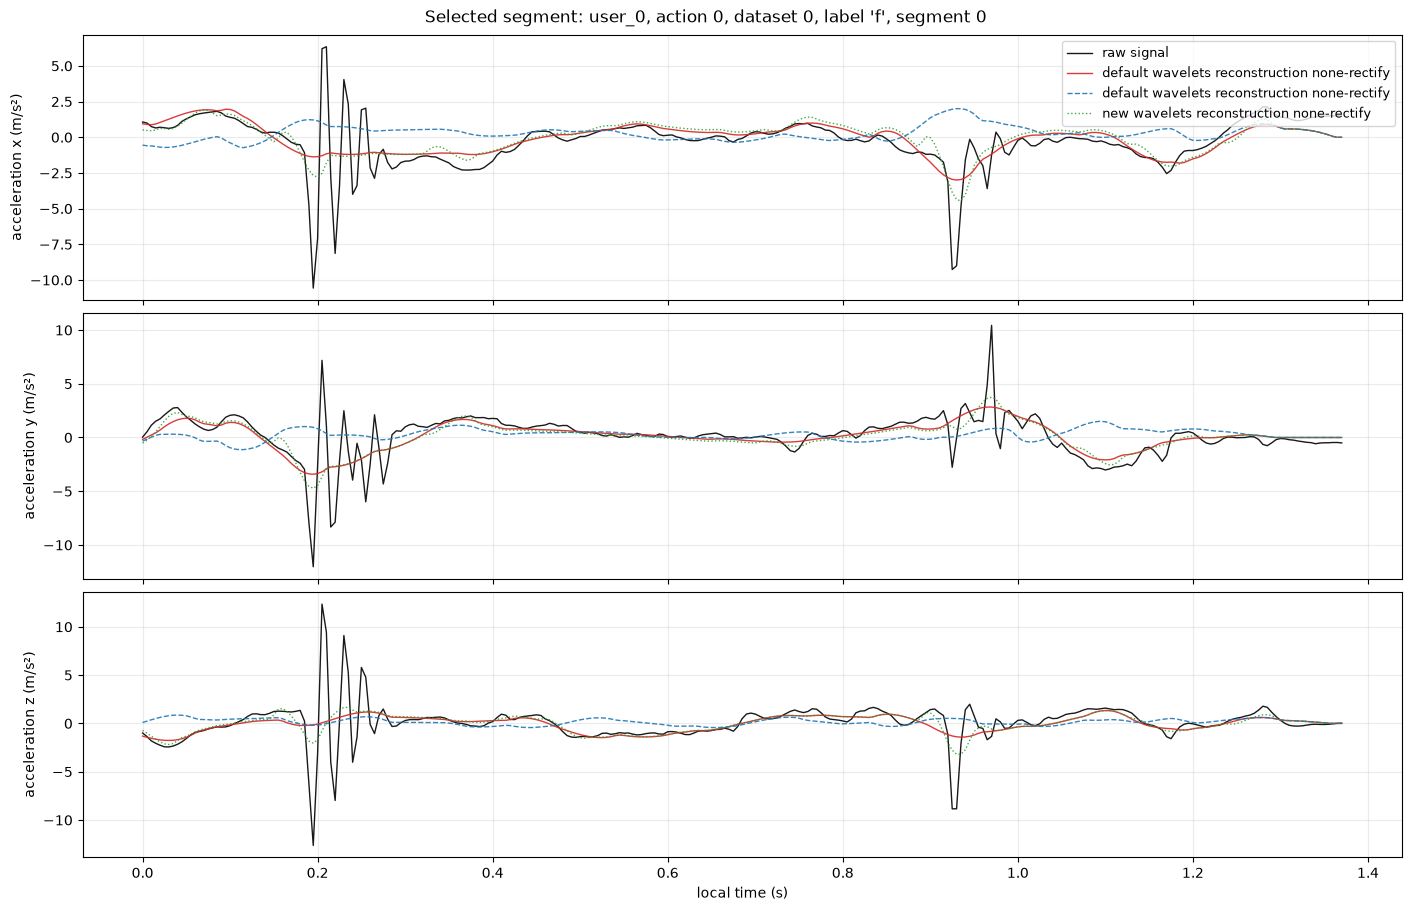

In [10]:
if PLOT_ENABLED:
    time_s = np.arange(len(A_RAW), dtype=np.float64) / SAMPLING_RATE_HZ
    series = (
        ("raw signal", A_RAW, "black", "-"),
        ("default wavelets reconstruction none-rectify", RECONSTRUCTIONS["A"], "tab:red", "-"),
        ("default wavelets reconstruction none-rectify", RECONSTRUCTIONS["B"], "tab:blue", "--"),
        ("new wavelets reconstruction none-rectify", RECONSTRUCTIONS["C"], "tab:green", ":"),
    )

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, layout="constrained")
    for axis_index, (axis, axis_name) in enumerate(zip(axes, AXIS_NAMES, strict=True)):
        for name, values, color, linestyle in series:
            axis.plot(
                time_s,
                values[:, axis_index],
                label=name,
                color=color,
                linestyle=linestyle,
                linewidth=1.0,
                alpha=0.9,
            )
        axis.set_ylabel(f"acceleration {axis_name} (m/s²)")
        axis.grid(True, alpha=0.25)
        if axis_index == 0:
            axis.legend(loc="upper right", fontsize=9)

    axes[-1].set_xlabel("local time (s)")
    fig.suptitle(
        f"Selected segment: {IDENTITY.user}, action {IDENTITY.action}, dataset {IDENTITY.dataset_id}, "
        f"label {IDENTITY.label!r}, segment {IDENTITY.segment_index}"
    )
    if SAVE_FIGURE:
        figure_path = resolve_path(OUTPUT_FIGURE)
        figure_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(figure_path, dpi=180, bbox_inches="tight")
        print(f"Saved figure: {figure_path}")
    plt.show()